# Observation Map

Geographic visualization of observer samples from `data/processed/observations/observations.csv`.

Shows spatial distribution of labeled observations across the Northeast, with density
estimation in crowded regions. Useful for identifying geographic gaps in coverage and
understanding which areas are well-represented in training data.

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from config import OBSERVATIONS_DIR, STAGE_NAMES

OBS_PATH = OBSERVATIONS_DIR / 'observations.csv'
print(f'Loading: {OBS_PATH}')

obs = pd.read_csv(OBS_PATH)
obs['date'] = pd.to_datetime(obs['date'])
obs['year'] = obs['date'].dt.year
obs['month'] = obs['date'].dt.month
obs['stage_name'] = obs['stage'].map({i: n for i, n in enumerate(STAGE_NAMES)})

print(f'Total observations: {len(obs)}')
print(f'Years: {sorted(obs["year"].unique())}')
print(f'\nStage distribution:')
print(obs['stage_name'].value_counts().to_string())
print(f'\nSources:')
print(obs['source'].value_counts().to_string())

Loading: C:\Users\Matthew Dannenberg\Desktop\Projects\foliage_detection\data\processed\observations\observations.csv
Total observations: 27487
Years: [np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]

Stage distribution:
stage_name
0    11775
2     8339
1     7346
3       27

Sources:
source
USA-NPN    27487


In [3]:
# ---------------------------------------------------------------------------
# Map settings — edit these and re-run the map cell
# ---------------------------------------------------------------------------

FILTER_STAGE  = None    # 'no_transition' | 'early' | 'peak' | 'late' | None (all)
FILTER_SOURCE = None    # e.g. 'USA-NPN' | None (all)
FILTER_YEAR   = None    # e.g. 2019 | None (all)
FILTER_MONTH  = None    # e.g. 10 (October) | None (all)

# Color points by this column
COLOR_BY = 'stage_name'   # 'stage_name' | 'source' | 'year' | 'confidence'

# Show KDE density heatmap underneath the scatter points
SHOW_DENSITY = True

# Map extent — defaults to Northeast; adjust if needed
LON_MIN, LON_MAX = -80.6, -66.8
LAT_MIN, LAT_MAX =  38.8,  47.6

# Point size and alpha
POINT_SIZE  = 20
POINT_ALPHA = 0.75

In [4]:
# ---------------------------------------------------------------------------
# Apply filters
# ---------------------------------------------------------------------------

filtered = obs.copy()
if FILTER_STAGE:
    filtered = filtered[filtered['stage_name'] == FILTER_STAGE]
if FILTER_SOURCE:
    filtered = filtered[filtered['source'] == FILTER_SOURCE]
if FILTER_YEAR:
    filtered = filtered[filtered['year'] == FILTER_YEAR]
if FILTER_MONTH:
    filtered = filtered[filtered['month'] == FILTER_MONTH]

# Clip to map extent
filtered = filtered[
    (filtered['longitude'] >= LON_MIN) & (filtered['longitude'] <= LON_MAX) &
    (filtered['latitude']  >= LAT_MIN) & (filtered['latitude']  <= LAT_MAX)
]

print(f'Observations after filtering: {len(filtered)}')
print(f'Unique locations: {filtered.groupby(["latitude","longitude"]).ngroups}')

Observations after filtering: 27487
Unique locations: 1151


In [5]:
# ---------------------------------------------------------------------------
# Color mapping helpers
# ---------------------------------------------------------------------------

STAGE_COLORS = {
    'no_transition': '#2ecc71',
    'early':         '#f39c12',
    'peak':          '#e74c3c',
    'late':          '#7f8c8d',
}

def make_color_mapping(df, col):
    """Return (colors_array, legend_elements) for a given column."""
    if col == 'stage_name':
        colors = df['stage_name'].map(STAGE_COLORS).fillna('#cccccc')
        legend = [Line2D([0],[0], marker='o', color='w',
                         markerfacecolor=c, markersize=8, label=s)
                  for s, c in STAGE_COLORS.items()]
        return colors.values, legend, None

    elif col == 'source':
        sources  = df['source'].unique()
        palette  = plt.cm.tab10(np.linspace(0, 1, len(sources)))
        src_map  = {s: palette[i] for i, s in enumerate(sources)}
        colors   = df['source'].map(lambda s: src_map[s])
        legend   = [Line2D([0],[0], marker='o', color='w',
                           markerfacecolor=src_map[s], markersize=8, label=s)
                    for s in sources]
        return colors.values, legend, None

    elif col == 'year':
        years   = sorted(df['year'].unique())
        norm    = mcolors.Normalize(vmin=min(years), vmax=max(years))
        cmap    = plt.cm.viridis
        colors  = df['year'].map(lambda y: cmap(norm(y)))
        sm      = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        return colors.values, None, sm

    elif col == 'confidence':
        norm   = mcolors.Normalize(vmin=0, vmax=1)
        cmap   = plt.cm.plasma
        colors = df['confidence'].map(lambda c: cmap(norm(c)))
        sm     = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        return colors.values, None, sm

    else:
        return ['steelblue'] * len(df), None, None

print('Color helpers ready.')

Color helpers ready.


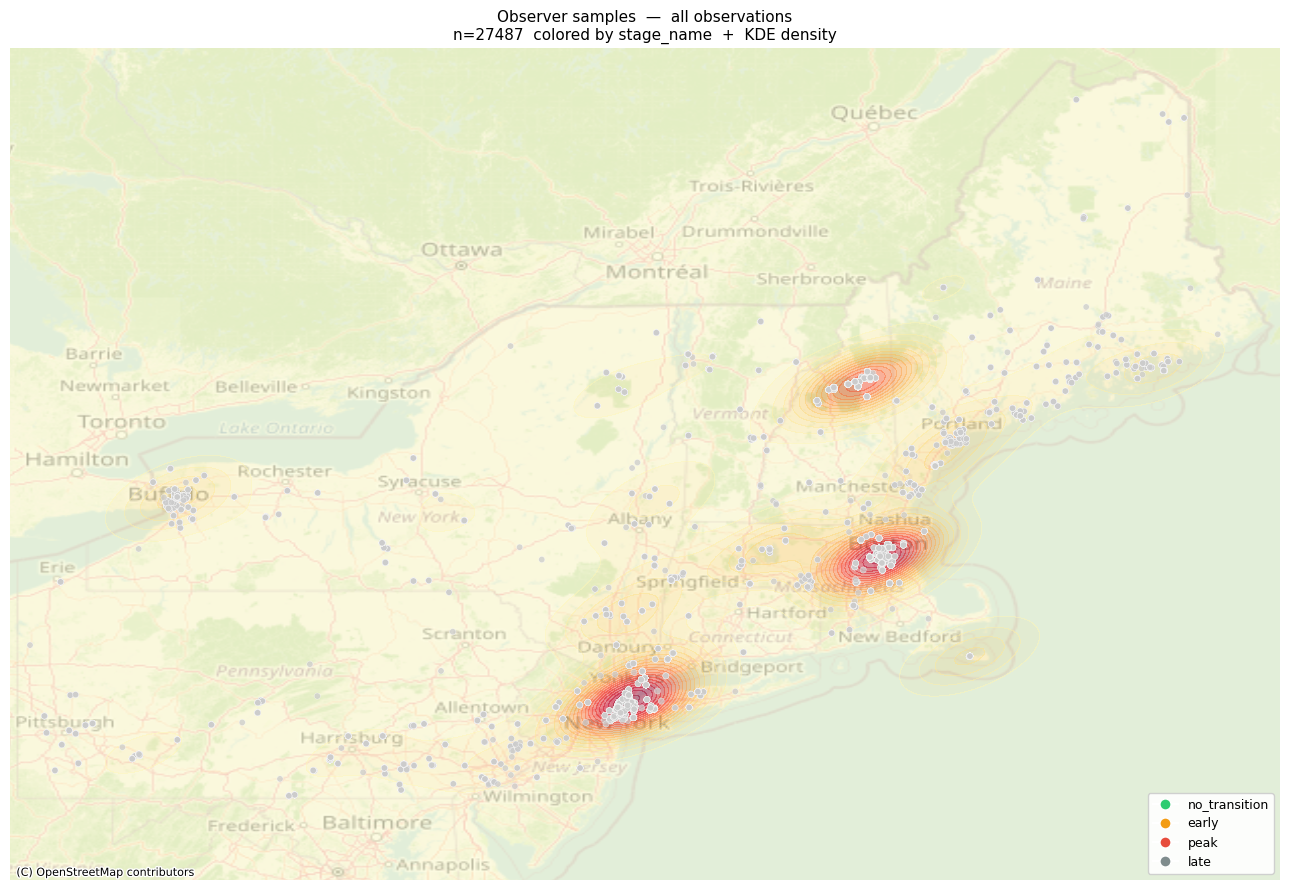

In [9]:
# ---------------------------------------------------------------------------
# Main map
# ---------------------------------------------------------------------------

if len(filtered) == 0:
    print('No observations match the current filters.')
else:
    try:
        import contextily as ctx
        from pyproj import Transformer
        HAS_CONTEXTILY = True
    except ImportError:
        HAS_CONTEXTILY = False
        print('contextily not found — install with: pip install contextily')
        print('Falling back to plain axes.')

    fig, ax = plt.subplots(figsize=(13, 9))

    lons = filtered['longitude'].values
    lats = filtered['latitude'].values

    if HAS_CONTEXTILY:
        # contextily works in Web Mercator (EPSG:3857), so we project
        # our WGS84 lon/lat before plotting, then add the tile basemap.
        transformer = Transformer.from_crs('EPSG:4326', 'EPSG:3857', always_xy=True)

        # Project observation points
        lons_m, lats_m = transformer.transform(lons, lats)

        # Project map extent corners
        xmin, ymin = transformer.transform(LON_MIN, LAT_MIN)
        xmax, ymax = transformer.transform(LON_MAX, LAT_MAX)

        # KDE in projected coordinates
        if SHOW_DENSITY and len(filtered) >= 10:
            x_grid = np.linspace(xmin, xmax, 300)
            y_grid = np.linspace(ymin, ymax, 300)
            x_mesh, y_mesh = np.meshgrid(x_grid, y_grid)
            kde = gaussian_kde(np.vstack([lons_m, lats_m]), bw_method='scott')
            density = kde(np.vstack([x_mesh.ravel(), y_mesh.ravel()])).reshape(x_mesh.shape)
            ax.contourf(x_mesh, y_mesh, density, levels=20,
                        cmap='YlOrRd', alpha=0.45, zorder=2)

        # Scatter
        colors, legend_elements, sm = make_color_mapping(filtered, COLOR_BY)
        ax.scatter(lons_m, lats_m, c=colors, s=POINT_SIZE, alpha=POINT_ALPHA,
                   linewidths=0.3, edgecolors='white', zorder=5)

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)

        # Add basemap tiles — Stamen Terrain shows topography nicely
        # Falls back to OpenStreetMap if Stamen is unavailable
        try:
            ctx.add_basemap(ax, source=ctx.providers.Stamen.TerrainBackground,
                            zorder=1, alpha=0.8)
        except Exception:
            ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik,
                            zorder=1, alpha=0.6)

        ax.set_axis_off()  # tiles carry their own context; axes labels add noise

    else:
        # Plain fallback — KDE and scatter in WGS84
        if SHOW_DENSITY and len(filtered) >= 10:
            lon_grid = np.linspace(LON_MIN, LON_MAX, 300)
            lat_grid = np.linspace(LAT_MIN, LAT_MAX, 300)
            lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
            kde = gaussian_kde(np.vstack([lons, lats]), bw_method='scott')
            density = kde(np.vstack([lon_mesh.ravel(), lat_mesh.ravel()])).reshape(lon_mesh.shape)
            ax.contourf(lon_mesh, lat_mesh, density, levels=20,
                        cmap='YlOrRd', alpha=0.35)

        colors, legend_elements, sm = make_color_mapping(filtered, COLOR_BY)
        ax.scatter(lons, lats, c=colors, s=POINT_SIZE, alpha=POINT_ALPHA,
                   linewidths=0.3, edgecolors='white', zorder=5)
        for lat in range(39, 48):
            ax.axhline(lat, color='lightgray', linewidth=0.4, zorder=0)
        for lon in range(-80, -66):
            ax.axvline(lon, color='lightgray', linewidth=0.4, zorder=0)
        ax.set_xlim(LON_MIN, LON_MAX)
        ax.set_ylim(LAT_MIN, LAT_MAX)
        ax.set_xlabel('Longitude', fontsize=10)
        ax.set_ylabel('Latitude', fontsize=10)

    # Legend / colorbar
    if legend_elements:
        ax.legend(handles=legend_elements, loc='lower right',
                  framealpha=0.9, fontsize=9)
    if sm:
        plt.colorbar(sm, ax=ax, label=COLOR_BY, shrink=0.7)

    filter_str = '  |  '.join(filter(None, [
        f'stage={FILTER_STAGE}' if FILTER_STAGE else None,
        f'source={FILTER_SOURCE}' if FILTER_SOURCE else None,
        f'year={FILTER_YEAR}' if FILTER_YEAR else None,
        f'month={FILTER_MONTH}' if FILTER_MONTH else None,
    ])) or 'all observations'

    ax.set_title(
        f'Observer samples  —  {filter_str}\n'
        f'n={len(filtered)}  colored by {COLOR_BY}'
        + ('  +  KDE density' if SHOW_DENSITY else ''),
        fontsize=11
    )

    plt.tight_layout()
    plt.show()

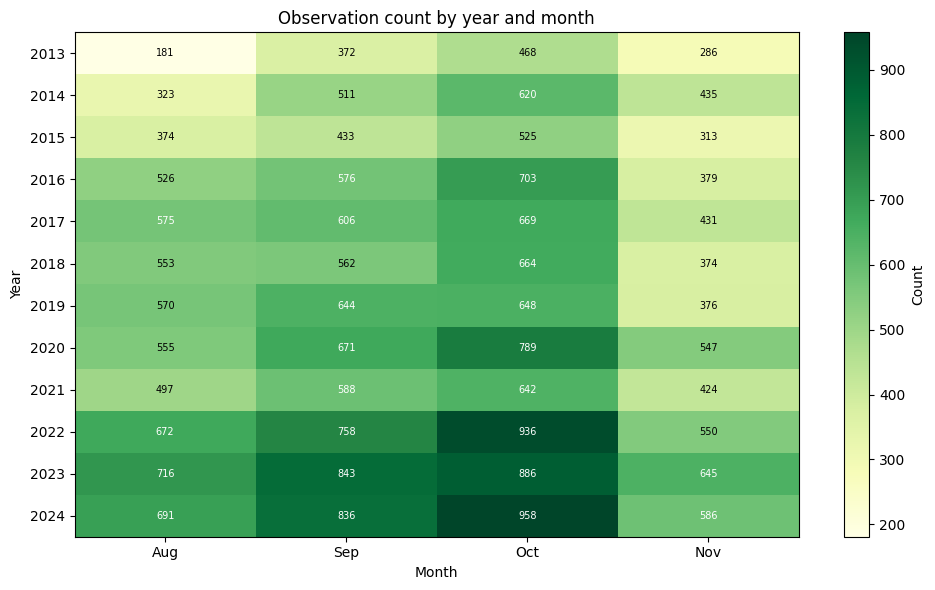

In [7]:
# ---------------------------------------------------------------------------
# Temporal coverage heatmap
# Shows observation count by year × month, revealing gaps in temporal coverage
# ---------------------------------------------------------------------------

pivot = obs.groupby(['year', 'month']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlGn')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    [m - 1] for m in pivot.columns
)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('Month')
ax.set_ylabel('Year')
ax.set_title('Observation count by year and month')
plt.colorbar(im, ax=ax, label='Count')

# Annotate cells with counts
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if val > 0:
            ax.text(j, i, str(val), ha='center', va='center',
                    fontsize=7,
                    color='white' if val > pivot.values.max() * 0.6 else 'black')

plt.tight_layout()
plt.show()

In [8]:
# ---------------------------------------------------------------------------
# Stage × source breakdown table
# ---------------------------------------------------------------------------

breakdown = obs.groupby(['stage_name', 'source']).agg(
    count=('confidence', 'count'),
    mean_conf=('confidence', 'mean'),
    n_locations=('latitude', lambda x: x.nunique()),
).round(3)

print('Observations by stage and source:')
print(breakdown.to_string())

print('\nUnique sites by stage:')
print(obs.groupby('stage_name').apply(
    lambda g: g.groupby(['latitude','longitude']).ngroups
).to_string())

Observations by stage and source:
                    count  mean_conf  n_locations
stage_name source                                
0          USA-NPN  11775      0.713          810
1          USA-NPN   7346      0.530          712
2          USA-NPN   8339      0.583          727
3          USA-NPN     27      0.531            9

Unique sites by stage:
stage_name
0    844
1    748
2    760
3     10


C:\Users\Matthew Dannenberg\AppData\Local\Temp\ipykernel_7156\1153006981.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(obs.groupby('stage_name').apply(
